# 🛒 Retail OS — Object Detection & Share of Shelf Analytics
### YOLOv8-based Retail Shelf Analysis with Model Optimization
**Auto-detects CPU vs GPU — works on both**

---

## 📦 1. Install Dependencies

In [ ]:
!pip install ultralytics opencv-python-headless matplotlib seaborn pandas numpy scikit-learn PyYAML --quiet

## 📚 2. Imports & Auto Device Detection

In [1]:
import os, cv2, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from collections import defaultdict, Counter
from ultralytics import YOLO
import torch
import warnings
warnings.filterwarnings('ignore')

# ── Auto device config ─────────────────────────────────────────────
CUDA   = torch.cuda.is_available()
DEVICE = 0 if CUDA else 'cpu'

# GPU  → YOLOv8x (maximum accuracy)
# CPU  → YOLOv8s (fast enough for CPU, still very capable)
MODEL_WEIGHTS = 'yolov8x.pt' if CUDA else 'yolov8s.pt'
BATCH         = 16 if CUDA else 4
IMGSZ         = 640 if CUDA else 480
EPOCHS        = 100 if CUDA else 50
WORKERS       = 4 if CUDA else 0   # MUST be 0 on CPU (avoids deadlock)
AMP           = CUDA                # Mixed precision only on GPU

print('=' * 52)
print('  DEVICE CONFIGURATION')
print('=' * 52)
print(f'  CUDA Available : {CUDA}')
print(f'  Device         : {DEVICE}')
print(f'  Model          : {MODEL_WEIGHTS}')
print(f'  Batch Size     : {BATCH}')
print(f'  Image Size     : {IMGSZ}')
print(f'  Epochs         : {EPOCHS}')
print(f'  Workers        : {WORKERS}')
print(f'  AMP            : {AMP}')
print('=' * 52)

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('ggplot')
sns.set_palette('husl')
print('\n✅ Setup complete!')

  DEVICE CONFIGURATION
  CUDA Available : False
  Device         : cpu
  Model          : yolov8s.pt
  Batch Size     : 4
  Image Size     : 480
  Epochs         : 50
  Workers        : 0
  AMP            : False

✅ Setup complete!


## 📂 3. Dataset Setup

In [2]:
DATASET_ROOT = Path('.')
TRAIN_IMG = DATASET_ROOT / 'train' / 'images'
TRAIN_LBL = DATASET_ROOT / 'train' / 'labels'
VALID_IMG = DATASET_ROOT / 'valid' / 'images'
VALID_LBL = DATASET_ROOT / 'valid' / 'labels'
TEST_IMG  = DATASET_ROOT / 'test'  / 'images'
TEST_LBL  = DATASET_ROOT / 'test'  / 'labels'
DATA_YAML = DATASET_ROOT / 'data.yaml'

assert DATA_YAML.exists(), f'data.yaml not found at {DATA_YAML.resolve()}'

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = cfg['names']
NC = len(CLASS_NAMES)

def n_imgs(p):
    return sum(len(list(p.glob(f'*.{e}'))) for e in ['jpg','jpeg','png'])

print(f'Classes ({NC}): {CLASS_NAMES}')
print(f'Train: {n_imgs(TRAIN_IMG)} | Valid: {n_imgs(VALID_IMG)} | Test: {n_imgs(TEST_IMG)}')

Classes (76): ['q1', 'q10', 'q100', 'q103', 'q106', 'q109', 'q112', 'q115', 'q118', 'q121', 'q13', 'q130', 'q133', 'q136', 'q142', 'q145', 'q148', 'q151', 'q157', 'q16', 'q163', 'q169', 'q175', 'q178', 'q184', 'q187', 'q19', 'q190', 'q193', 'q196', 'q199', 'q202', 'q211', 'q214', 'q22', 'q220', 'q229', 'q232', 'q247', 'q25', 'q250', 'q256', 'q262', 'q265', 'q268', 'q271', 'q274', 'q280', 'q286', 'q289', 'q291', 'q293', 'q299', 'q31', 'q34', 'q37', 'q4', 'q40', 'q46', 'q49', 'q52', 'q55', 'q58', 'q61', 'q64', 'q67', 'q7', 'q70', 'q73', 'q76', 'q79', 'q82', 'q88', 'q91', 'q94', 'q97']
Train: 924 | Valid: 40 | Test: 35


## 🔍 4. Exploratory Data Analysis

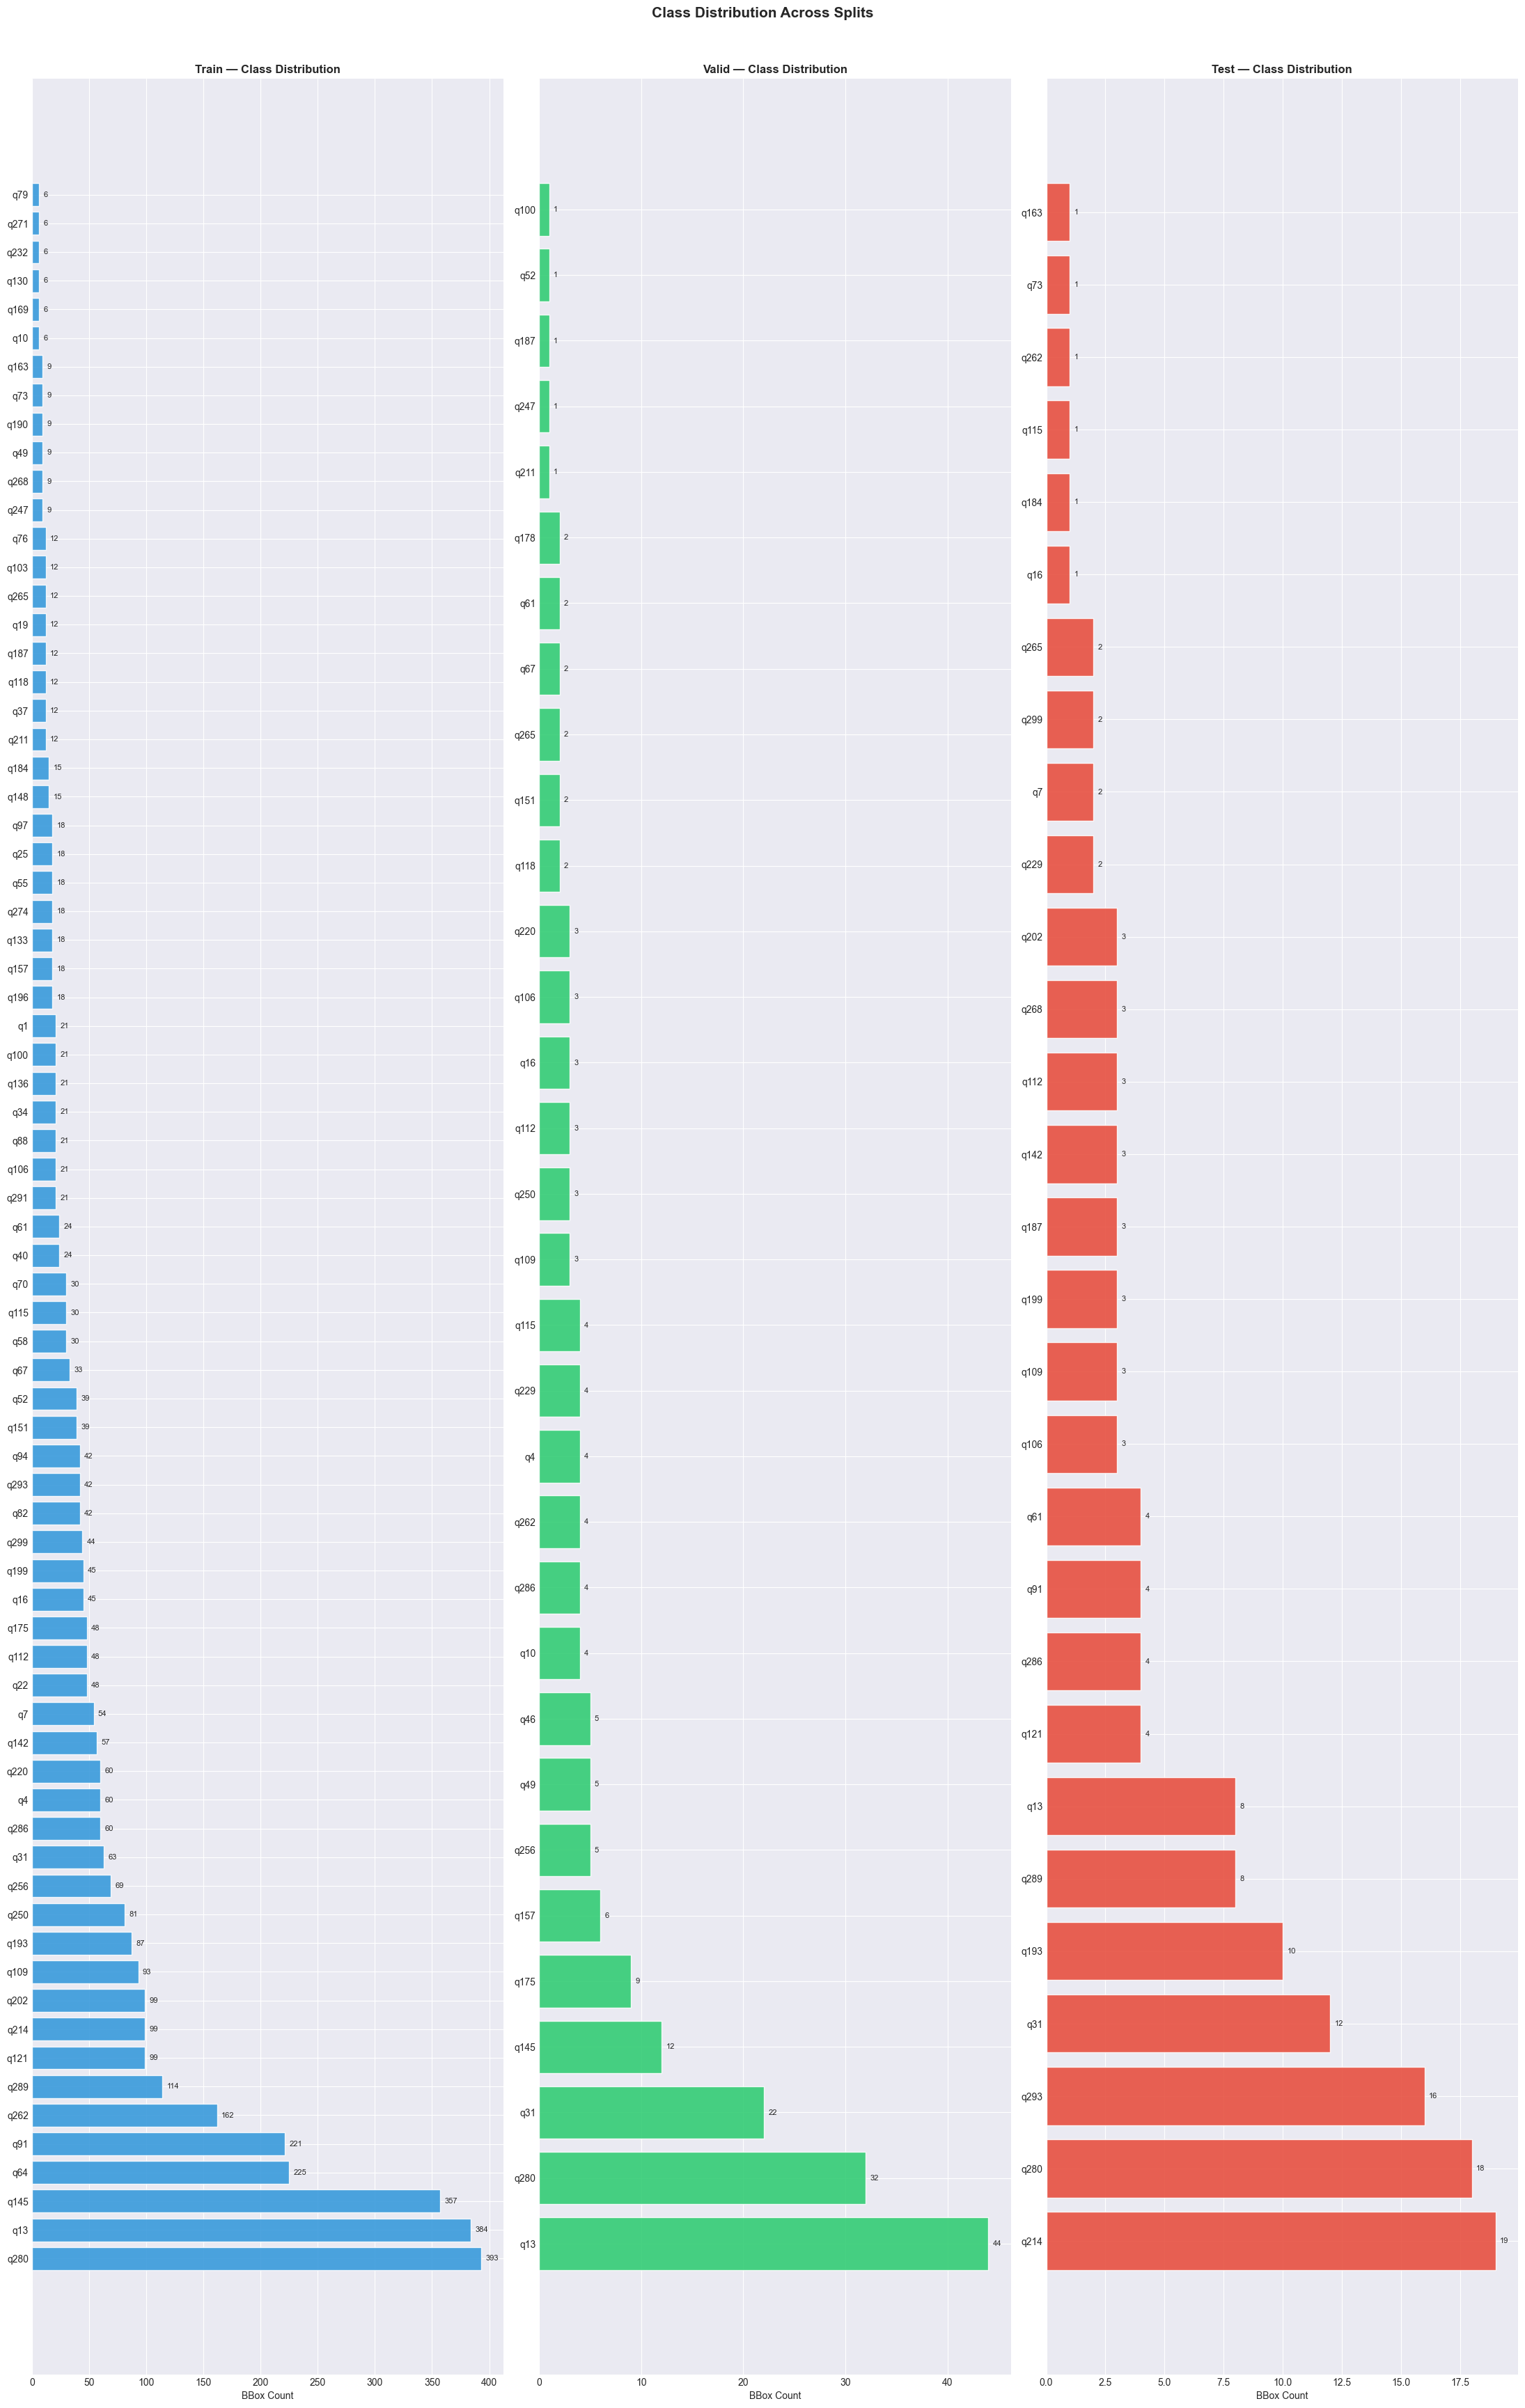

✅ Class distribution saved


In [3]:
def cls_dist(lbl_dir):
    c = Counter()
    for f in Path(lbl_dir).glob('*.txt'):
        for line in open(f):
            p = line.split()
            if p and int(p[0]) < NC:
                c[CLASS_NAMES[int(p[0])]] += 1
    return c

splits = [('Train', cls_dist(TRAIN_LBL), '#3498DB'),
          ('Valid', cls_dist(VALID_LBL),  '#2ECC71'),
          ('Test',  cls_dist(TEST_LBL),   '#E74C3C')]

fig, axes = plt.subplots(1, 3, figsize=(22, max(5, NC * 0.45)))
for ax, (title, counts, color) in zip(axes, splits):
    if not counts:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue
    names, vals = zip(*sorted(counts.items(), key=lambda x: -x[1]))
    ax.barh(names, vals, color=color, alpha=0.88, edgecolor='white')
    for i, v in enumerate(vals):
        ax.text(v + max(vals)*0.01, i, str(v), va='center', fontsize=8)
    ax.set_title(f'{title} — Class Distribution', fontweight='bold')
    ax.set_xlabel('BBox Count')

plt.suptitle('Class Distribution Across Splits', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Class distribution saved')

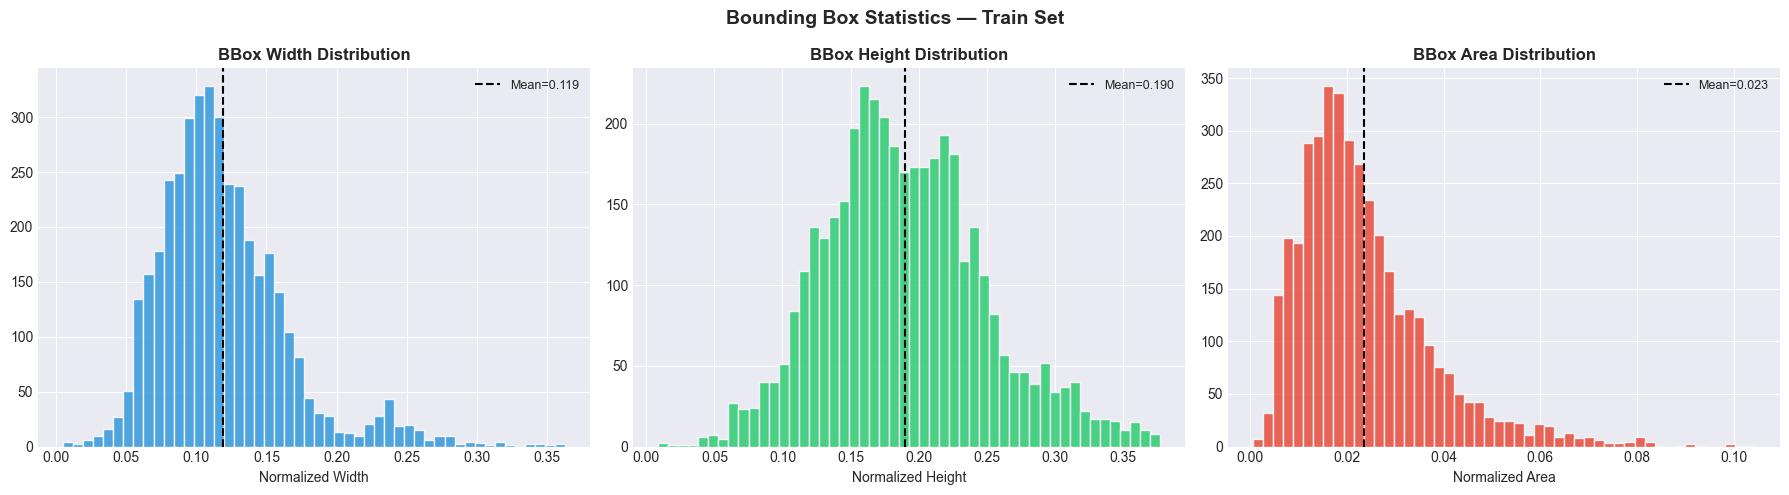

Avg W=0.1191 | H=0.1900 | Area=0.023487


In [4]:
ws, hs, areas = [], [], []
for f in TRAIN_LBL.glob('*.txt'):
    for line in open(f):
        p = line.split()
        if len(p) == 5:
            _, cx, cy, w, h = map(float, p)
            ws.append(w); hs.append(h); areas.append(w*h)

if ws:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, data, lbl, col in zip(axes,
        [ws, hs, areas],
        ['Width', 'Height', 'Area'],
        ['#3498DB', '#2ECC71', '#E74C3C']):
        ax.hist(data, bins=50, color=col, alpha=0.85, edgecolor='white')
        ax.axvline(np.mean(data), color='black', linestyle='--', label=f'Mean={np.mean(data):.3f}')
        ax.set_title(f'BBox {lbl} Distribution', fontweight='bold')
        ax.set_xlabel(f'Normalized {lbl}'); ax.legend(fontsize=9)
    plt.suptitle('Bounding Box Statistics — Train Set', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('bbox_statistics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Avg W={np.mean(ws):.4f} | H={np.mean(hs):.4f} | Area={np.mean(areas):.6f}')

## 🚀 5. Model Training

### Recall Optimization Strategy
| Technique | Impact |
|---|---|
| YOLOv8s (CPU) / YOLOv8x (GPU) | Strong backbone for dense shelves |
| `mosaic=1.0` + `mixup=0.15` + `copy_paste=0.2` | Heavy augmentation → fewer misses |
| `AdamW` + `cos_lr=True` | Smooth convergence |
| `conf=0.001` during training | Model sees all detections during NMS |
| `workers=0` on CPU | Prevents multiprocessing deadlock |
| `amp=False` on CPU | Avoids unsupported half-precision ops |

In [5]:
print(f'Loading {MODEL_WEIGHTS} ...')
model = YOLO(MODEL_WEIGHTS)

print(f'\nStarting training on device={DEVICE}  |  epochs={EPOCHS}  |  batch={BATCH}\n')

results = model.train(
    data     = str(DATA_YAML),
    epochs   = EPOCHS,
    imgsz    = IMGSZ,
    batch    = BATCH,
    device   = DEVICE,
    workers  = WORKERS,
    amp      = AMP,
    project  = 'retail_os',
    name     = 'yolov8_optimized',
    exist_ok = True,

    # Optimizer
    optimizer    = 'AdamW',
    lr0          = 0.001,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 0.0005,
    warmup_epochs   = 3,
    warmup_momentum = 0.8,
    cos_lr       = True,

    # Loss weights
    box = 7.5,
    cls = 0.5,
    dfl = 1.5,

    # Augmentation (key for recall)
    hsv_h      = 0.015,
    hsv_s      = 0.7,
    hsv_v      = 0.4,
    degrees    = 5.0,
    translate  = 0.1,
    scale      = 0.5,
    shear      = 2.0,
    flipud     = 0.1,
    fliplr     = 0.5,
    mosaic     = 1.0,
    mixup      = 0.15,
    copy_paste = 0.2,

    # Inference defaults
    conf    = 0.001,
    iou     = 0.6,

    patience = 20,
    save     = True,
    plots    = True,
    verbose  = True,
)

BEST = 'retail_os/yolov8_optimized/weights/best.pt'
print(f'\n✅ Training complete! Best model → {BEST}')

Loading yolov8s.pt ...

Starting training on device=cpu  |  epochs=50  |  batch=4

Ultralytics 8.4.19  Python-3.11.14 torch-2.10.0+cpu CPU (12th Gen Intel Core i5-12400)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.001, copy_paste=0.2, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=5.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.6, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_optimized, nbs=64, nms=False, opset=None

## 📊 6. Confidence Threshold Sweep

In [6]:
model_eval = YOLO(BEST)

CONF_RANGE = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
sweep = []

print(f'  {"conf":<6}  {"P":>8}  {"R":>8}  {"mAP50":>8}  {"F1":>8}')
print('  ' + '-'*42)
for ct in CONF_RANGE:
    vr = model_eval.val(data=str(DATA_YAML), split='val',
                        conf=ct, iou=0.5,
                        device=DEVICE, workers=WORKERS, verbose=False)
    P  = float(vr.box.mp)
    R  = float(vr.box.mr)
    m  = float(vr.box.map50)
    F1 = 2*P*R/(P+R+1e-9)
    sweep.append({'conf':ct,'P':round(P,4),'R':round(R,4),'mAP50':round(m,4),'F1':round(F1,4)})
    print(f'  {ct:<6.2f}  {P:>8.4f}  {R:>8.4f}  {m:>8.4f}  {F1:>8.4f}')

df_sw = pd.DataFrame(sweep)
print('\n✅ Sweep complete')

FileNotFoundError: [Errno 2] No such file or directory: 'retail_os\\yolov8_optimized\\weights\\best.pt'

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
sc = ax1.scatter(df_sw['R'], df_sw['P'], c=df_sw['conf'], cmap='RdYlGn_r', s=130, zorder=5)
ax1.plot(df_sw['R'], df_sw['P'], 'b--', alpha=0.4)
for _, row in df_sw.iterrows():
    ax1.annotate(f"{row['conf']:.2f}", (row['R'], row['P']),
                 textcoords='offset points', xytext=(5,4), fontsize=8)
plt.colorbar(sc, ax=ax1, label='Confidence Threshold')
ax1.set_xlabel('Recall'); ax1.set_ylabel('Precision')
ax1.set_title('Precision vs Recall', fontweight='bold'); ax1.grid(alpha=0.3)

ax2 = axes[1]
x = df_sw['conf']
ax2.plot(x, df_sw['P'],     'b^-', label='Precision', lw=2, ms=8)
ax2.plot(x, df_sw['R'],     'gs-', label='Recall',    lw=2, ms=8)
ax2.plot(x, df_sw['F1'],    'ro-', label='F1',        lw=2, ms=8)
ax2.plot(x, df_sw['mAP50'], 'mv-', label='mAP50',     lw=2, ms=8)
ax2.axhline(0.676, color='gray', linestyle=':', alpha=0.7, label='Baseline Recall 67.6%')
ax2.set_xlabel('Confidence Threshold'); ax2.set_ylabel('Score')
ax2.set_title('Metrics vs Confidence Threshold', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle('Threshold Analysis — Recall/Precision Tradeoff', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Pick threshold with highest F1 where R >= 0.75 (else pick max R)
hi_r = df_sw[df_sw['R'] >= 0.75]
best_row = hi_r.loc[hi_r['F1'].idxmax()] if len(hi_r) else df_sw.loc[df_sw['R'].idxmax()]
OPT_CONF = float(best_row['conf'])
OPT_IOU  = 0.5
print(f'\nOptimal threshold selected: conf={OPT_CONF}')
print(f'  P={best_row["P"]}  R={best_row["R"]}  F1={best_row["F1"]}')

## 🧪 7. Test Set Evaluation

In [ ]:
print(f'Test evaluation | conf={OPT_CONF} | iou={OPT_IOU}\n')
tr = model_eval.val(data=str(DATA_YAML), split='test',
                    conf=OPT_CONF, iou=OPT_IOU,
                    device=DEVICE, workers=WORKERS,
                    verbose=True, plots=True)

P  = float(tr.box.mp)
R  = float(tr.box.mr)
m5 = float(tr.box.map50)
m  = float(tr.box.map)
F1 = 2*P*R/(P+R+1e-9)
fm = {'Precision':P,'Recall':R,'mAP@50':m5,'mAP@50-95':m,'F1':F1}

print('\n' + '='*58)
print('   FINAL TEST SET METRICS')
print('='*58)
for k,v in fm.items():
    print(f'  {k:<14}: {v:.4f}  {"█"*int(v*32)}')
imp = (R - 0.676)*100
print('='*58)
print(f'  Recall: 67.6% → {R*100:.1f}%  ({"+" if imp>=0 else ""}{imp:.1f}pp)')

## 🏪 8. Share of Shelf Analytics

In [7]:
test_imgs = [p for ext in ['jpg','jpeg','png'] for p in TEST_IMG.glob(f'*.{ext}')]
print(f'Running inference on {len(test_imgs)} test images...')

preds = model_eval.predict(source=str(TEST_IMG), conf=OPT_CONF, iou=OPT_IOU,
                           imgsz=IMGSZ, device=DEVICE, workers=WORKERS,
                           verbose=False, save=False)

det_cnt  = Counter()
area_sum = defaultdict(float)
conf_sum = defaultdict(float)
tot_det  = 0; tot_area = 0.0

for pred in preds:
    if pred.boxes is None: continue
    for box in pred.boxes:
        cid = int(box.cls[0])
        cname = CLASS_NAMES[cid] if cid < NC else f'cls_{cid}'
        cv = float(box.conf[0])
        xywhn = box.xywhn[0].tolist()
        a = xywhn[2] * xywhn[3]
        det_cnt[cname]  += 1
        area_sum[cname] += a
        conf_sum[cname] += cv
        tot_det += 1; tot_area += a

print(f'Total detections: {tot_det} | Unique SKUs: {len(det_cnt)}')

Running inference on 35 test images...


NameError: name 'model_eval' is not defined

In [8]:
rows = []
for cn in CLASS_NAMES:
    c = det_cnt.get(cn,0)
    a = area_sum.get(cn,0.0)
    rows.append({'SKU':cn,'Detections':c,
                 'Count Share (%)': round(c/max(tot_det,1)*100,2),
                 'Area Share (%)' : round(a/max(tot_area,1e-12)*100,2),
                 'Avg Area'       : round(a/max(c,1),6),
                 'Avg Conf'       : round(conf_sum[cn]/max(c,1),3)})

df_shelf = pd.DataFrame(rows).sort_values('Count Share (%)',ascending=False).reset_index(drop=True)
print(df_shelf.to_string(index=False))
df_shelf.to_csv('share_of_shelf_analytics.csv', index=False)
print('\n✅ Saved: share_of_shelf_analytics.csv')

NameError: name 'det_cnt' is not defined

## 📊 9. Share of Shelf — Visualizations

In [9]:
df_act  = df_shelf[df_shelf['Detections']>0].copy()
pal     = sns.color_palette('husl', len(df_act))

fig, axes = plt.subplots(2,2,figsize=(22,18))
fig.suptitle('Share of Shelf Analytics Dashboard', fontsize=18, fontweight='bold', y=1.01)

# Count share bar
ax1 = axes[0,0]
ds = df_act.sort_values('Count Share (%)')
b  = ax1.barh(ds['SKU'], ds['Count Share (%)'], color=pal[:len(ds)], alpha=0.9, edgecolor='white')
for bar,v in zip(b, ds['Count Share (%)']):
    ax1.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
ax1.axvline(100/max(len(ds),1), color='red', ls='--', alpha=0.6, label='Equal Share')
ax1.set_title('Count-Based Share of Shelf', fontweight='bold', fontsize=13)
ax1.set_xlabel('Share (%)'); ax1.legend(fontsize=9); ax1.grid(axis='x',alpha=0.3)

# Area share bar
ax2 = axes[0,1]
da = df_act.sort_values('Area Share (%)')
b2 = ax2.barh(da['SKU'], da['Area Share (%)'], color=pal[:len(da)], alpha=0.9, edgecolor='white')
for bar,v in zip(b2, da['Area Share (%)']):
    ax2.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
ax2.set_title('Area-Weighted Share of Shelf', fontweight='bold', fontsize=13)
ax2.set_xlabel('Area Share (%)'); ax2.grid(axis='x',alpha=0.3)

# Donut
ax3 = axes[1,0]
ax3.pie(df_act['Count Share (%)'], labels=df_act['SKU'], autopct='%1.1f%%',
        colors=pal[:len(df_act)], wedgeprops=dict(width=0.55,edgecolor='white',linewidth=2),
        startangle=90, textprops={'fontsize':8})
ax3.set_title('SKU Distribution Donut', fontweight='bold', fontsize=13)

# Grouped bar
ax4 = axes[1,1]
top = df_act.head(min(15,len(df_act)))
x, w = np.arange(len(top)), 0.38
ax4.bar(x-w/2, top['Count Share (%)'], w, label='Count %', color='#3498DB', alpha=0.88, edgecolor='white')
ax4.bar(x+w/2, top['Area Share (%)'],  w, label='Area %',  color='#E74C3C', alpha=0.88, edgecolor='white')
ax4.set_xticks(x); ax4.set_xticklabels(top['SKU'], rotation=40, ha='right', fontsize=8)
ax4.set_title('Count vs Area Share per SKU', fontweight='bold', fontsize=13)
ax4.set_ylabel('Share (%)'); ax4.legend(); ax4.grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.savefig('share_of_shelf_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved')

NameError: name 'df_shelf' is not defined

In [ ]:
# Heatmap
if len(df_act):
    fig, ax = plt.subplots(figsize=(max(14,len(df_act)), 6))
    hm = df_act.set_index('SKU')[['Count Share (%)','Area Share (%)','Avg Conf']].T
    im = ax.imshow(hm.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(hm.columns))); ax.set_xticklabels(hm.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(hm.index)));   ax.set_yticklabels(hm.index, fontsize=11)
    vmax = hm.values.max()
    for i in range(len(hm.index)):
        for j in range(len(hm.columns)):
            v = hm.values[i,j]
            ax.text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=8,fontweight='bold',
                    color='white' if v>vmax*0.6 else 'black')
    plt.colorbar(im,ax=ax,fraction=0.02,pad=0.04)
    ax.set_title('Shelf Metrics Heatmap per SKU', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('shelf_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Heatmap saved')

## 🖼️ 10. Sample Inference Visualizations

In [ ]:
COLORS = (plt.cm.hsv(np.linspace(0,1,max(NC,1)))[:,:3]*255).astype(int)
samples = test_imgs[:6]

nc, nr = min(3,len(samples)), (len(samples)+2)//3
fig, axes = plt.subplots(nr,nc,figsize=(7*nc,6*nr))
axes = np.array(axes).reshape(nr,nc)
fig.suptitle('Sample Test Predictions', fontsize=16, fontweight='bold')

for idx, ip in enumerate(samples):
    ax = axes[idx//nc][idx%nc]
    img = cv2.cvtColor(cv2.imread(str(ip)), cv2.COLOR_BGR2RGB)
    res = model_eval.predict(source=str(ip), conf=OPT_CONF, iou=OPT_IOU,
                             device=DEVICE, verbose=False)[0]
    ax.imshow(img)
    nd = 0
    if res.boxes is not None:
        nd = len(res.boxes)
        for box in res.boxes:
            cid = int(box.cls[0])
            cv_ = float(box.conf[0])
            x1,y1,x2,y2 = box.xyxy[0].tolist()
            col = tuple(COLORS[cid%len(COLORS)]/255)
            ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,lw=1.5,edgecolor=col,facecolor='none'))
            ax.text(x1,y1-3,f'{CLASS_NAMES[cid][:10]} {cv_:.2f}',color='white',fontsize=6,
                    bbox=dict(facecolor=col,alpha=0.75,pad=0.5,edgecolor='none'))
    ax.set_title(f'{ip.name[:25]} | {nd} items', fontsize=9); ax.axis('off')

for idx in range(len(samples), nr*nc):
    axes[idx//nc][idx%nc].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: sample_predictions.png')

## 📋 11. Final Summary Report

In [ ]:
print('='*62)
print('         FINAL SUMMARY REPORT')
print('='*62)
print(f'  Device    : {"GPU (CUDA)" if CUDA else "CPU"}')
print(f'  Model     : {MODEL_WEIGHTS}')
print(f'  conf={OPT_CONF}  iou={OPT_IOU}')
print('-'*62)
print('  TEST SET METRICS')
for k,v in fm.items():
    print(f'    {k:<14}: {v:.4f}  {"█"*int(v*28)}')
imp=(R-0.676)*100
print(f'\n  Recall: 67.6% → {R*100:.1f}%  ({"+" if imp>=0 else ""}{imp:.1f}pp)')
print('-'*62)
print('  SHARE OF SHELF')
print(f'    Total detections : {tot_det}')
print(f'    SKUs detected    : {len(det_cnt)} / {NC}')
print()
print('  Top 5 SKUs (Count Share):')
for _,row in df_shelf[df_shelf['Detections']>0].head(5).iterrows():
    print(f'    {row["SKU"]:<22} {row["Count Share (%)"]:>6.2f}%  {"█"*max(1,int(row["Count Share (%)"]/2))}')
print('-'*62)
print('  OUTPUT FILES')
for f in ['class_distribution.png','bbox_statistics.png','threshold_analysis.png',
          'share_of_shelf_dashboard.png','share_of_shelf_analytics.csv',
          'shelf_heatmap.png','sample_predictions.png',
          'retail_os/yolov8_optimized/weights/best.pt']:
    print(f'    ✅ {f}')
print('='*62)